In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

# Set style
sns.set_theme(color_codes=True)
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
from google.colab import files
print(" Please upload your placement dataset:")
uploaded = files.upload()


filename = list(uploaded.keys())[0]
print(f" File uploaded: {filename}")

 Please upload your placement dataset:


Saving local_college_placements.csv to local_college_placements.csv
 File uploaded: local_college_placements.csv


In [3]:
df = pd.read_csv(filename)
print(f" Dataset shape: {df.shape}")
display(df.head())

 Dataset shape: (1050, 11)


,Student_ID,Gender,Branch,CGPA,Internships,Backlogs,Programming_Skills,Aptitude_Score,Communication_Skills,Extra_Certifications,Placement_Status
0,STU0001,Male,IT,7.66,2,0,Beginner,97.6,Average,0,Placed
1,STU0002,Female,IT,8.44,1,2,Advanced,75.5,Average,3,Placed
2,STU0003,Female,ECE,7.16,1,2,Beginner,76.8,Average,1,Not Placed
3,STU0004,Male,ME,6.14,1,1,Intermediate,55.4,Good,3,Placed
4,STU0005,Male,ME,6.82,2,0,Advanced,65.9,Poor,2,Placed


In [4]:
print(" Column names in dataset:")
for col in df.columns:
    print(f"  - '{col}'")

 Column names in dataset:
  - 'Student_ID'
  - 'Gender'
  - 'Branch'
  - 'CGPA'
  - 'Internships'
  - 'Backlogs'
  - 'Programming_Skills'
  - 'Aptitude_Score'
  - 'Communication_Skills'
  - 'Extra_Certifications'
  - 'Placement_Status'


In [5]:
if 'Placement_Status' in df.columns:
    df.rename(columns={'Placement_Status': 'status'}, inplace=True)
    print(" Renamed 'Placement_Status' → 'status'")

if 'status' in df.columns:
    df['status'] = df['status'].map({'Placed': 1, 'Not Placed': 0})
    print(" Converted target values: Placed=1, Not Placed=0")

print("\n Updated column names:")
print(df.columns.tolist())
print("\n Target distribution:")
print(df['status'].value_counts())

 Renamed 'Placement_Status' → 'status'
 Converted target values: Placed=1, Not Placed=0

 Updated column names:
['Student_ID', 'Gender', 'Branch', 'CGPA', 'Internships', 'Backlogs', 'Programming_Skills', 'Aptitude_Score', 'Communication_Skills', 'Extra_Certifications', 'status']

 Target distribution:
status
1    538
0    512
Name: count, dtype: int64


In [6]:
if 'Student_ID' in df.columns:
    df.drop(columns=['Student_ID'], inplace=True)
    print(" Dropped 'Student_ID' column")

print(f"\n New dataset shape: {df.shape}")
display(df.head())

 Dropped 'Student_ID' column

 New dataset shape: (1050, 10)


,Gender,Branch,CGPA,Internships,Backlogs,Programming_Skills,Aptitude_Score,Communication_Skills,Extra_Certifications,status
0,Male,IT,7.66,2,0,Beginner,97.6,Average,0,1
1,Female,IT,8.44,1,2,Advanced,75.5,Average,3,1
2,Female,ECE,7.16,1,2,Beginner,76.8,Average,1,0
3,Male,ME,6.14,1,1,Intermediate,55.4,Good,3,1
4,Male,ME,6.82,2,0,Advanced,65.9,Poor,2,1


In [7]:
check_missing = df.isnull().sum() * 100 / df.shape[0]
missing_cols = check_missing[check_missing > 0].sort_values(ascending=False)

if len(missing_cols) > 0:
    print(" Columns with missing values:")
    print(missing_cols)
else:
    print(" No missing values found!")

 No missing values found!


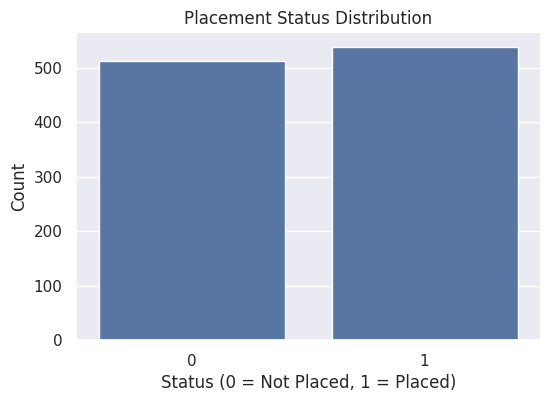

status
1    538
0    512
Name: count, dtype: int64

 Placement Rate: 51.24%


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='status')
plt.title('Placement Status Distribution')
plt.xlabel('Status (0 = Not Placed, 1 = Placed)')
plt.ylabel('Count')
plt.show()

print(df['status'].value_counts())
placement_rate = df['status'].mean() * 100
print(f"\n Placement Rate: {placement_rate:.2f}%")

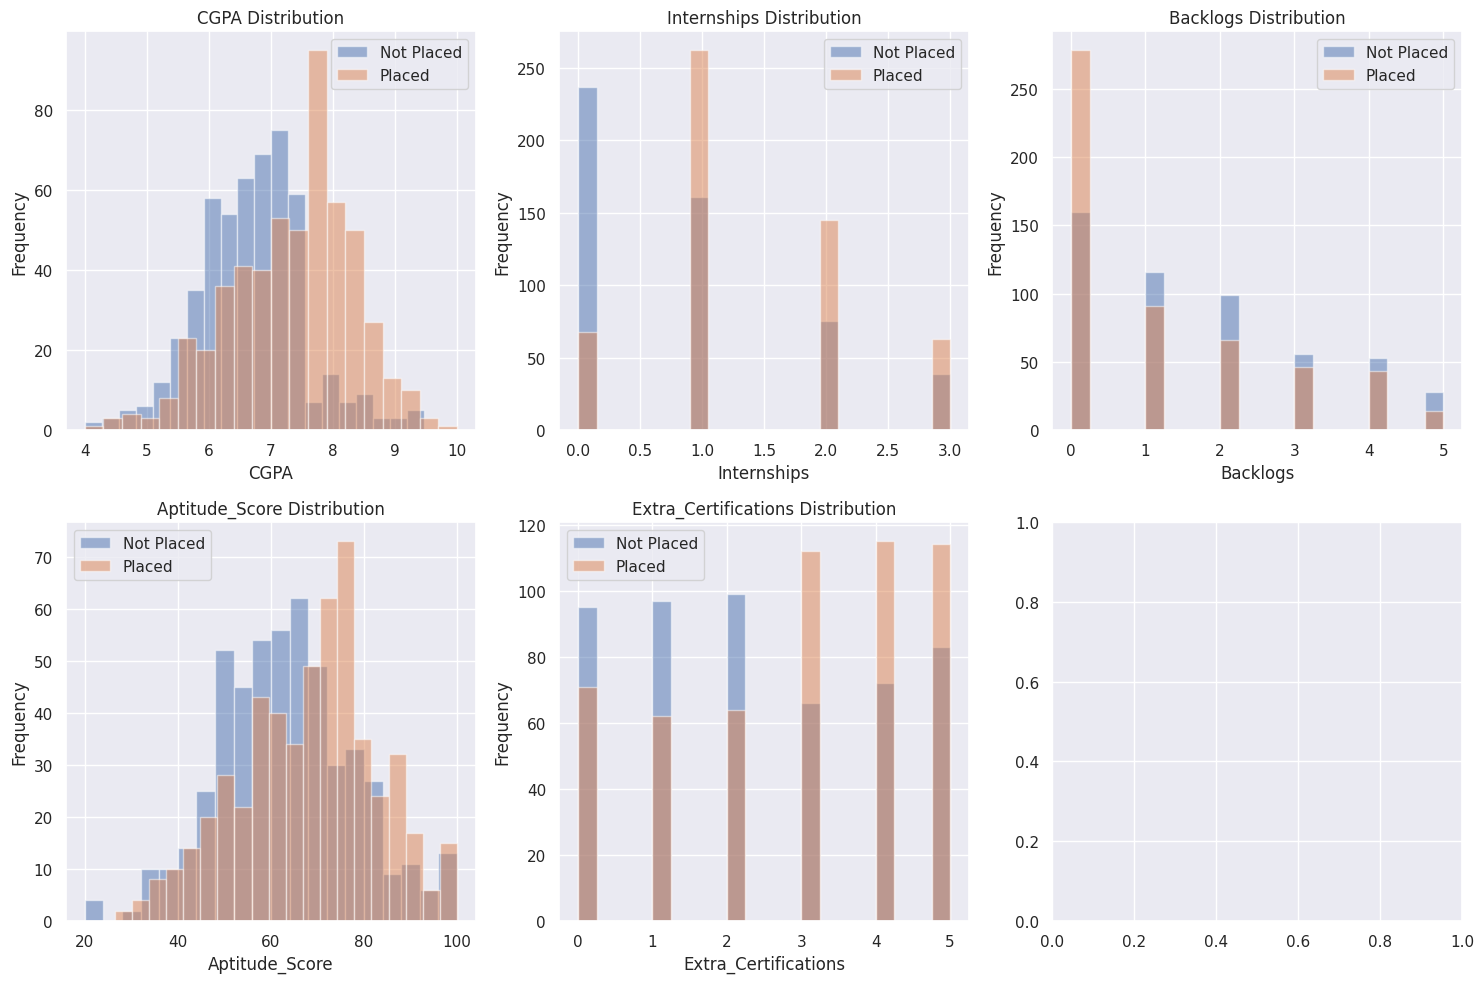

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col != 'status']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(num_cols[:6]):
    ax = axes[i]
    for status_val in [0, 1]:
        subset = df[df['status'] == status_val]
        status_label = 'Placed' if status_val == 1 else 'Not Placed'
        ax.hist(subset[col], bins=20, alpha=0.5, label=status_label)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

In [11]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

print(" Correlation matrix calculated!")
print("\nCorrelations with Placement Status:")
print(correlation_matrix['status'].sort_values(ascending=False))

 Correlation matrix calculated!

Correlations with Placement Status:
status                  1.000000
CGPA                    0.336487
Internships             0.289174
Aptitude_Score          0.170943
Extra_Certifications    0.161372
Backlogs               -0.167830
Name: status, dtype: float64


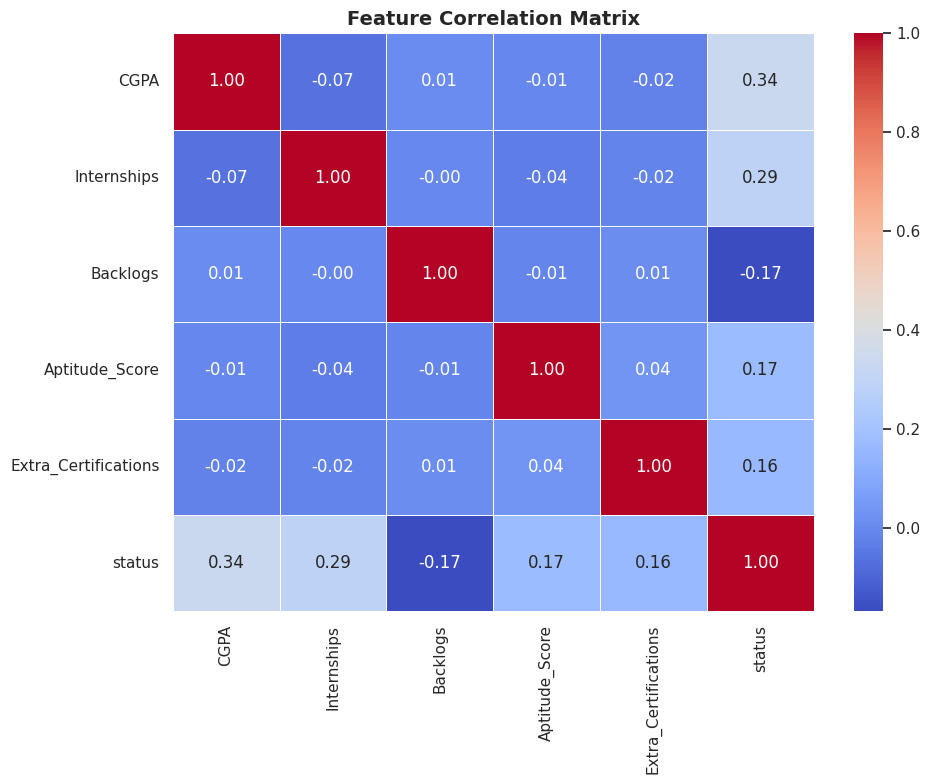

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.select_dtypes(include=['object']).columns:
    print(f"\n Encoding column: {col}")
    print(f"Original values: {df_encoded[col].unique()}")

    label_encoder = preprocessing.LabelEncoder()
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])
    label_encoders[col] = label_encoder

    print(f"Encoded values: {df_encoded[col].unique()}")

print("\n All categorical columns encoded!")
display(df_encoded.head())


 Encoding column: Gender
Original values: ['Male' 'Female']
Encoded values: [1 0]

 Encoding column: Branch
Original values: ['IT' 'ECE' 'ME' 'CE' 'CSE']
Encoded values: [3 2 4 0 1]

 Encoding column: Programming_Skills
Original values: ['Beginner' 'Advanced' 'Intermediate']
Encoded values: [1 0 2]

 Encoding column: Communication_Skills
Original values: ['Average' 'Good' 'Poor']
Encoded values: [0 1 2]

 All categorical columns encoded!


,Gender,Branch,CGPA,Internships,Backlogs,Programming_Skills,Aptitude_Score,Communication_Skills,Extra_Certifications,status
0,1,3,7.66,2,0,1,97.6,0,0,1
1,0,3,8.44,1,2,0,75.5,0,3,1
2,0,2,7.16,1,2,1,76.8,0,1,0
3,1,4,6.14,1,1,2,55.4,1,3,1
4,1,4,6.82,2,0,0,65.9,2,2,1


In [15]:
X = df_encoded.drop('status', axis=1)
y = df_encoded['status']

print(" Features (X) shape:", X.shape)
print(" Target (y) shape:", y.shape)
print("\n Feature names:")
print(X.columns.tolist())

 Features (X) shape: (1050, 9)
 Target (y) shape: (1050,)

 Feature names:
['Gender', 'Branch', 'CGPA', 'Internships', 'Backlogs', 'Programming_Skills', 'Aptitude_Score', 'Communication_Skills', 'Extra_Certifications']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f" Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f" Testing set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

 Training set size: 735 (70.0%)
 Testing set size: 315 (30.0%)


In [17]:
logreg_model = LogisticRegression(solver='lbfgs', max_iter=4000, random_state=42)
logreg_model.fit(X_train, y_train)

print(" Model trained successfully!")

 Model trained successfully!


In [18]:
y_train_pred = logreg_model.predict(X_train)
y_test_pred = logreg_model.predict(X_test)
y_test_proba = logreg_model.predict_proba(X_test)[:, 1]

print(" Predictions complete!")

 Predictions complete!


In [19]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_proba)
cv_scores = cross_val_score(logreg_model, X, y, cv=5)

print(f" Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f" Testing Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f" ROC-AUC Score: {roc_auc:.4f}")
print(f" Cross-Validation Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

 Training Accuracy: 0.7388 (73.88%)
 Testing Accuracy: 0.7778 (77.78%)
 ROC-AUC Score: 0.8608
 Cross-Validation Score: 0.7495 (+/- 0.0428)


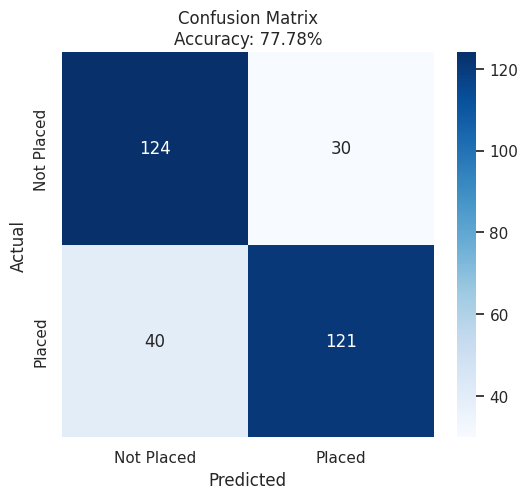

In [20]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'],
            yticklabels=['Not Placed', 'Placed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix\nAccuracy: {test_acc:.2%}')
plt.show()

In [21]:
print(" Classification Report:")
print(classification_report(y_test, y_test_pred,
                           target_names=['Not Placed', 'Placed']))

 Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.76      0.81      0.78       154
      Placed       0.80      0.75      0.78       161

    accuracy                           0.78       315
   macro avg       0.78      0.78      0.78       315
weighted avg       0.78      0.78      0.78       315



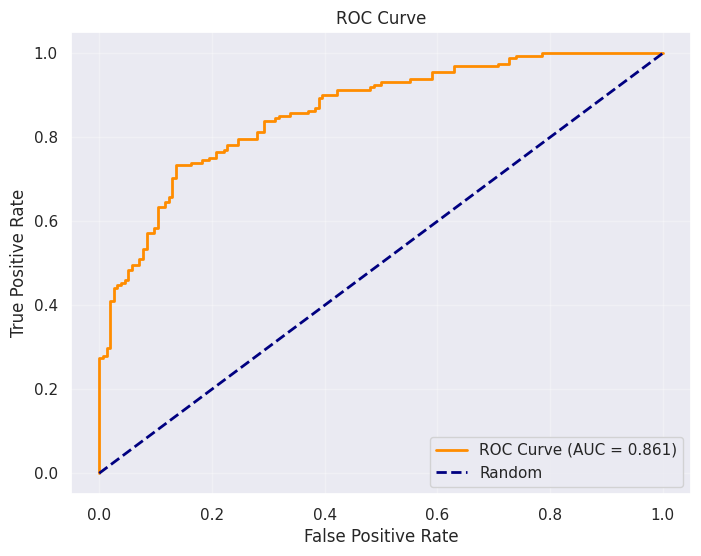

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

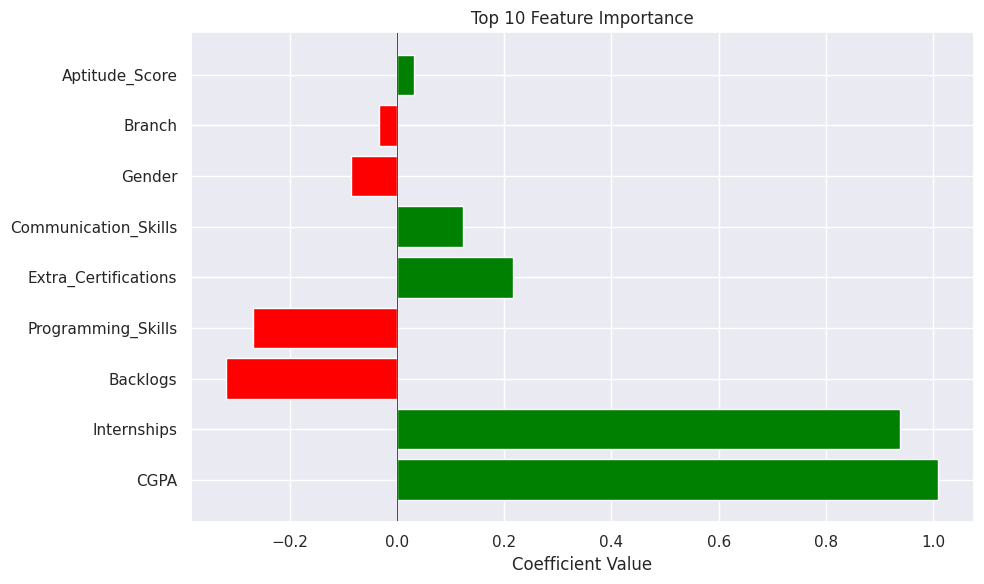

 Top Features:
             Feature  Coefficient  Abs_Coefficient
                CGPA     1.009748         1.009748
         Internships     0.938640         0.938640
            Backlogs    -0.318490         0.318490
  Programming_Skills    -0.268124         0.268124
Extra_Certifications     0.215772         0.215772
Communication_Skills     0.123363         0.123363
              Gender    -0.086022         0.086022
              Branch    -0.033412         0.033412
      Aptitude_Score     0.031749         0.031749


In [23]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg_model.coef_[0],
    'Abs_Coefficient': np.abs(logreg_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in feature_importance['Coefficient'].head(10)]
plt.barh(feature_importance['Feature'].head(10),
         feature_importance['Coefficient'].head(10),
         color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Feature Importance')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print(" Top Features:")
print(feature_importance.head(10).to_string(index=False))

In [24]:
print("=" * 50)
print(" LOGISTIC REGRESSION SUMMARY")
print("=" * 50)
print(f"🔹 Training Accuracy: {train_acc:.2%}")
print(f"🔹 Testing Accuracy: {test_acc:.2%}")
print(f"🔹 ROC-AUC Score: {roc_auc:.3f}")
print(f"🔹 Cross-Validation: {cv_scores.mean():.2%} (+/- {cv_scores.std()*2:.2%})")
print(f"🔹 Features Used: {X.shape[1]}")
print(f"🔹 Training Samples: {len(X_train)}")
print(f"🔹 Testing Samples: {len(X_test)}")
print("=" * 50)

 LOGISTIC REGRESSION SUMMARY
🔹 Training Accuracy: 73.88%
🔹 Testing Accuracy: 77.78%
🔹 ROC-AUC Score: 0.861
🔹 Cross-Validation: 74.95% (+/- 4.28%)
🔹 Features Used: 9
🔹 Training Samples: 735
🔹 Testing Samples: 315
